<a href="https://colab.research.google.com/github/hersh-4/CSC-442-Group-Project/blob/main/CSC_442_HW_6_Query_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
merged_dataset = pd.read_csv('merged_dataset.csv')

# Display first few rows
merged_dataset.head()


,state_name,county_fips,county_name,votes_gop,votes_dem,total_votes,diff,per_gop,per_dem,per_point_diff,...,Annual Healthcare,Annual Other Necessities,Annual Childcare,Annual Taxes,Annual Total,median_family_income,num_counties_in_st,st_cost_rank,st_med_aff_rank,st_income_rank
0,Alabama,1001,Autauga County,20484,7439,28190,13045.0,0.726641,0.263888,0.462753,...,15542.13558,8851.80505,10535.61214,13662.01629,93477.5104,83452.0,67.0,8.0,48.0,11.0
1,Alabama,1003,Baldwin County,95798,24934,121808,70864.0,0.786467,0.204699,0.581768,...,14644.38907,9746.87133,10351.86510,14544.30292,97116.7975,92918.0,67.0,2.0,59.0,4.0
2,Alabama,1005,Barbour County,5606,4158,9832,1448.0,0.570179,0.422905,0.147274,...,14356.61277,7070.95930,8055.20472,9870.87344,77551.0166,60474.0,67.0,63.0,19.0,55.0
3,Alabama,1007,Bibb County,7572,1619,9241,5953.0,0.819392,0.175197,0.644194,...,14823.93821,7025.80685,11188.32950,11808.59579,85717.8629,67222.0,67.0,18.0,20.0,39.0
4,Alabama,1009,Blount County,25354,2576,28115,22778.0,0.901796,0.091624,0.810173,...,14823.93821,6697.65267,11567.09626,11478.51394,84304.6712,76388.0,67.0,24.0,46.0,18.0


Data Preprocessing, Only keeping data relevant to regression


In [ ]:
# Define relevant economic indicators as features
features = ['median_family_income', 'Annual Taxes', 'Annual Housing',
            'Annual Food', 'Monthly Transportation']

# Define target variable
target = 'per_gop'

# Drop missing values
df = merged_dataset[features + [target]].dropna()

# Check dataset size after dropping missing values
print(f"Dataset size after preprocessing: {df.shape}")


Dataset size after preprocessing: (3104, 6)


# **Exploratory Data Analysis (EDA)**

Heatmap of Correlations

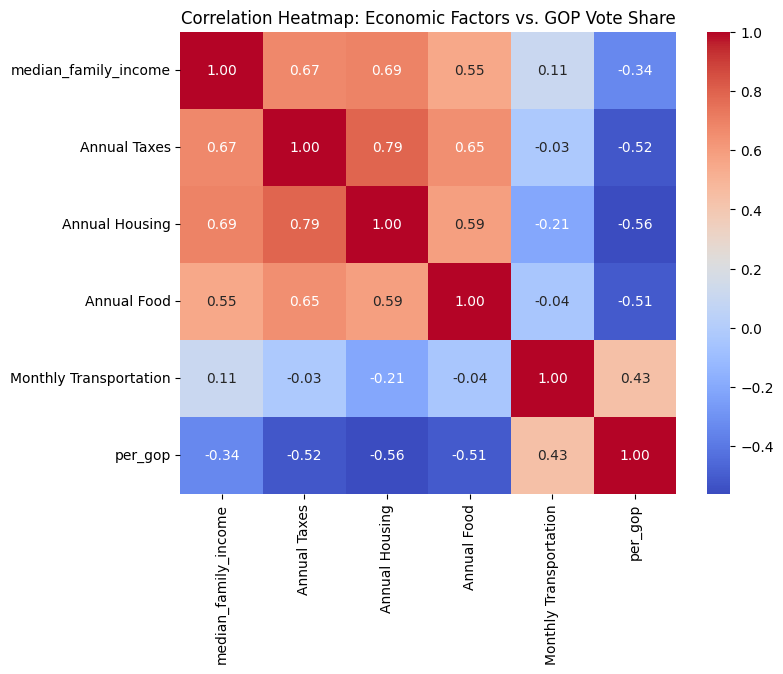

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap: Economic Factors vs. GOP Vote Share")
plt.show()


Scatter Plot: Median Income vs. GOP Vote Share

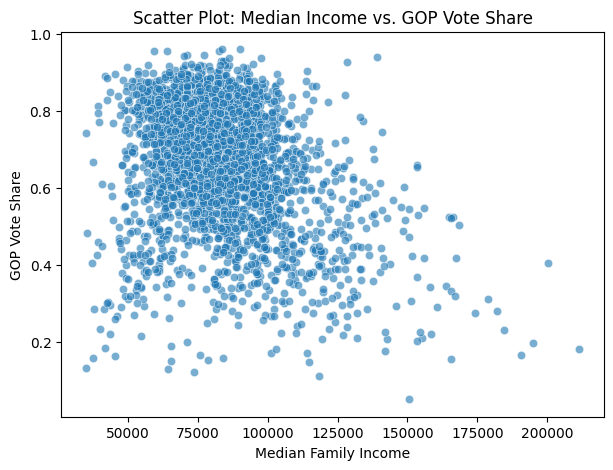

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=df['median_family_income'], y=df['per_gop'], alpha=0.6)
plt.xlabel("Median Family Income")
plt.ylabel("GOP Vote Share")
plt.title("Scatter Plot: Median Income vs. GOP Vote Share")
plt.show()


# **Train-Test Split & Regression Model**

Split data into training and testing sets

In [ ]:
X = df[features]  # Independent variables
y = df[target]    # Target variable

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape}")
print(f"Testing data size: {X_test.shape}")


Training data size: (2483, 5)
Testing data size: (621, 5)


# Build & Evaluate Linear Regression Model

Train Linear Regression

In [ ]:
# Initialize regression model
model = LinearRegression()

# Train model on training data
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)


# Model Evaluation

Calculate Performance Metrics

In [ ]:
# Calculate errors
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print evaluation results
print(f"Model Performance:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")


Model Performance:
Mean Absolute Error (MAE): 0.0895
Mean Squared Error (MSE): 0.0132
Root Mean Squared Error (RMSE): 0.1150
R² Score: 0.4859


# Cross-Validation for Model Robustness

In [ ]:
# Perform 5-fold cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print(f"Cross-Validation R² Scores: {cv_scores}")
print(f"Mean Cross-Validation R² Score: {cv_scores.mean():.4f}")


Cross-Validation R² Scores: [0.41777091 0.56831566 0.43177863 0.40920404 0.53573423]
Mean Cross-Validation R² Score: 0.4726
